In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

REPO_URL = 'https://github.com/Jdrice72901/DSBA-6211-Stack-overflow-Survey-Analysis.git'
REPO_DIR = Path('/content/Stack-Overflow-Survey-Analysis')
DRIVE_ROOT = Path('/content/drive/MyDrive/stack-overflow-survey-analysis')

In [ ]:
!pip install country_converter kmodes

In [ ]:
if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

/content/Stack-Overflow-Survey-Analysis


In [ ]:
from src import comp_clean

df = pd.read_parquet("data/derived/clean_core.parquet")

df['employment_group'] = df['employment_primary']
df['is_employed'] = df['is_paid_worker'].fillna(False).astype(bool)
df['age_group'] = pd.cut(
    pd.to_numeric(df['age_mid'], errors='coerce'),
    bins=[10, 25, 35, 45, 55, 100],
    labels=['Under 25', '25-34', '35-44', '45-54', '55+'],
    right=False
)

df = comp_clean.add_role_family_features(df)
df = comp_clean.add_log_comp_real(df)

employment_text = comp_clean.lower_text(df['employment'])
employment_addl_text = comp_clean.lower_text(df['employment_addl'])
student_text = comp_clean.lower_text(df['student'])

addl_part_time = employment_addl_text.str.contains(
    'engaged in paid work \\(less than 10 hours per week\\)|engaged in paid work \\(10-19 hours per week\\)|engaged in paid work \\(20-29 hours per week\\)',
    regex=True
)
addl_student = employment_addl_text.str.contains('attending school')
addl_retired = employment_addl_text.str.contains('transitioning to retirement')

df['is_independent'] = employment_text.str.contains('self-employed|independent contractor|freelance|contractor')
df['is_full_time_employed'] = employment_text.str.contains('full-time') | (employment_text.eq('employed') & ~addl_part_time)
df['is_part_time_employed'] = (employment_text.str.contains('part-time') | addl_part_time) & ~df['is_full_time_employed']
df['is_student_status'] = student_text.str.contains('yes|student') | employment_text.str.contains('student') | addl_student
df['is_retired_status'] = employment_text.str.contains('retired') | addl_retired
df['is_not_employed'] = employment_text.str.contains('not employed') & ~(
    df['is_full_time_employed'] |
    df['is_part_time_employed'] |
    df['is_independent']
)

In [4]:
cols_to_drop = [
    'ethnicity',
    'student',
    'undergrad_major',
    'age_first_code',
    'age_first_code_clean',
    'job_seek',
    'work_week_hrs',
    'work_week_hrs_clean',
    'learn_code_online',
    'coding_activities',
    'misc_tech',
    'webframe',
    'op_sys_prof',
    'ai_use',
    'ai_sent',
    'learn_code',
    'work_exp',
    'age_mid',
    'response_id',
    'main_branch',
    'gender',
    'country'
]

SAT_MAP = {
    "I hate my job":                                         1,
    "I'm somewhat dissatisfied with my job":                2,
    "I'm neither satisfied nor dissatisfied with my job":   3,
    "I'm neither satisfied nor dissatisfied":               3,
    "I'm somewhat satisfied with my job":                   4,
    "I love my job":                                         5,
    "I don't have a job":                                   np.nan,
    "Other (please specify)":                                np.nan,
    "Extremely dissatisfied":           1,
    "Moderately dissatisfied":          2,
    "Slightly dissatisfied":            2,
    "Neither satisfied nor dissatisfied": 3,
    "Slightly satisfied":               4,
    "Moderately satisfied":             4,
    "Extremely satisfied":              5,
    "Very dissatisfied":    1,
    "Very satisfied":       5,
}

def standardize_job_sat(row):
    val = row["job_sat"]
    year = row["survey_year"]

    if pd.isna(val):
        return np.nan

    if year in [2017, 2024, 2025]:
        try:
            v = float(val)
        except:
            return np.nan
        if v <= 1:
            return 1
        elif v <= 4:
            return 2
        elif v <= 6:
            return 3
        elif v <= 8:
            return 4
        else:
            return 5

    return SAT_MAP.get(val, np.nan)

df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
df_clean = df_clean[~df_clean['survey_year'].isin([2021, 2022, 2023])]

df_clean["job_sat_std"] = df_clean.apply(standardize_job_sat, axis=1)
df_model = df_clean[df_clean['job_sat_std'].notna()].copy()

In [5]:
cols_to_drop = [
    "row_id",
    "country_clean",
    "job_sat",
    "job_sat_num",
    "age",
    "employment",
    "education",
    "org_size",
    "remote",
    "years_code",
    "comp",
    "comp_usd_clean",
    "log_comp_usd_clean",
    "comp_real_2025",
    "language",
    "database",
    "platform",
]

EDU_MAP = {
    "Primary/elementary school":    "Below secondary",
    "Secondary school":             "Below secondary",
    "No formal education / other":  "Below secondary",
    "Other / ungrouped":            "Below secondary",
    "Some college/university":      "Some college",
    "Associate degree":             "Some college",
    "Bachelor's degree":            "Bachelor's",
    "Master's degree":              "Postgraduate",
    "Professional degree":          "Postgraduate",
    "Doctoral degree":              "Postgraduate",
}

df_model = df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns])

df_model["education_clean"] = (
    df_model["education_clean"]
    .map(EDU_MAP)
    .fillna("Unknown")
)

In [6]:
cont_features = [
    'years_code_clean',
    'language_count',
    'database_count',
    'platform_count',
    'log_comp_real_2025',
    'work_exp_clean',
    'experience_proxy_years',
    'professional_experience_years',
    'role_family_count'
]
cont_features = [c for c in cont_features if c in df_model.columns]

binary_features = [
    'is_employed',
    'is_professional',
    'role_back_end',
    'role_data_ml',
    'role_desktop_enterprise',
    'role_devops_cloud',
    'role_front_end',
    'role_full_stack',
    'role_management',
    'role_mobile',
    'role_other',
    'role_qa_testing',
    'role_student_academic'
]
binary_features = [c for c in binary_features if c in df_model.columns]

df_model_improved = df_model.copy()
for col in cont_features:
    df_model_improved[col] = pd.to_numeric(df_model_improved[col], errors='coerce')
for col in binary_features:
    if col in df_model_improved.columns and df_model_improved[col].dtype == bool:
        df_model_improved[col] = df_model_improved[col].astype(int)


for col in cont_features:
    lower = df_model_improved[col].quantile(0.01)
    upper = df_model_improved[col].quantile(0.99)
    df_model_improved[col] = df_model_improved[col].clip(lower=lower, upper=upper)

if 'years_code_clean' in df_model_improved.columns:
    df_model_improved['years_code_bin'] = pd.cut(
        df_model_improved['years_code_clean'],
        bins=[-np.inf, 2, 5, 10, 15, 20, np.inf],
        labels=['0-2', '3-5', '6-10', '11-15', '16-20', '21+']
    ).astype('category')

if 'log_comp_real_2025' in df_model_improved.columns:
    df_model_improved['comp_bin'] = pd.qcut(
        df_model_improved['log_comp_real_2025'],
        q=5,
        duplicates='drop'
    ).astype('category')

if 'language_count' in df_model_improved.columns:
    df_model_improved['language_count_bin'] = pd.cut(
        df_model_improved['language_count'],
        bins=[-np.inf, 1, 3, 5, 8, np.inf],
        labels=['0-1', '2-3', '4-5', '6-8', '9+']
    ).astype('category')

if 'database_count' in df_model_improved.columns:
    df_model_improved['database_count_bin'] = pd.cut(
        df_model_improved['database_count'],
        bins=[-np.inf, 1, 3, 5, 8, np.inf],
        labels=['0-1', '2-3', '4-5', '6-8', '9+']
    ).astype('category')

if 'platform_count' in df_model_improved.columns:
    df_model_improved['platform_count_bin'] = pd.cut(
        df_model_improved['platform_count'],
        bins=[-np.inf, 1, 3, 5, 8, np.inf],
        labels=['0-1', '2-3', '4-5', '6-8', '9+']
    ).astype('category')

if 'role_family_count' in df_model_improved.columns:
    df_model_improved['role_family_count_bin'] = pd.cut(
        df_model_improved['role_family_count'],
        bins=[-np.inf, 1, 2, 3, 4, np.inf],
        labels=['1', '2', '3', '4', '5+']
    ).astype('category')

In [7]:
#Clustering:
df_model_improved.columns

Index(['survey_year', 'region', 'employment_addl', 'employment_primary',
       'is_paid_worker', 'is_full_time_employed', 'is_part_time_employed',
       'is_independent', 'is_professional', 'education_clean',
       'org_size_clean', 'ic_or_pm', 'ic_or_pm_clean', 'dev_type', 'industry',
       'industry_clean', 'remote_group', 'language_count', 'database_count',
       'platform_count', 'years_code_clean', 'years_code_pro',
       'years_code_pro_clean', 'work_exp_clean', 'experience_proxy_source',
       'professional_experience_years', 'role_family', 'employment_group',
       'is_employed', 'age_group', 'role_family_count', 'role_advocacy_dx',
       'role_architecture', 'role_back_end', 'role_data_ml', 'role_design_ux',
       'role_desktop_enterprise', 'role_devops_cloud',
       'role_embedded_hardware', 'role_front_end', 'role_full_stack',
       'role_game_graphics', 'role_management', 'role_mobile', 'role_other',
       'role_qa_testing', 'role_security', 'role_student_acade

In [8]:
df_model_improved['is_student_status'].value_counts()

is_student_status
False    307872
True      29187
Name: count, dtype: int64

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

#For clustering, im only keeping what I think make most sense for behavioral segmentation
c_features = [
    "region",
    "age_group",
    "employment_primary",
    "is_student_status",
    "is_retired_status",
    "education_clean",
    "dev_type",
    "industry",
    "language_count",
    "years_code_clean",
    "professional_experience_years",
    "database_count",
    "platform_count",
    "org_size_clean",
    "remote_group"
]

df_cluster = df_model_improved[c_features].copy()
df_cluster_fin = df_model_improved[c_features].copy()

df_cluster['is_student_status'] = df_cluster['is_student_status'].astype(str).map({'True': 1, 'False': 0, 'nan': np.nan, 'None': np.nan}).astype(float)
df_cluster['is_retired_status'] = df_cluster['is_retired_status'].astype(str).map({'True': 1, 'False': 0, 'nan': np.nan, 'None': np.nan}).astype(float)

for col in df_cluster.select_dtypes(exclude=np.number).columns:
    df_cluster[col] = df_cluster[col].astype(str).where(df_cluster[col].notna() & (df_cluster[col].astype(str) != 'nan'), other=np.nan)
categorical_cols = df_cluster.select_dtypes(exclude=np.number).columns.tolist()
numeric_cols = df_cluster.select_dtypes(include=np.number).columns.tolist()
print(f'Categorical Features: {categorical_cols} \nNumerical Features: {numeric_cols}')

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')
df_cluster[numeric_cols] = num_imputer.fit_transform(df_cluster[numeric_cols])
df_cluster[categorical_cols] = cat_imputer.fit_transform(df_cluster[categorical_cols])
scaler = StandardScaler()
df_cluster[numeric_cols] = scaler.fit_transform(df_cluster[numeric_cols])
df_cluster[categorical_cols] = df_cluster[categorical_cols].astype(str)

features = categorical_cols + numeric_cols
data = df_cluster[features]
data_matrix = data.to_numpy()
categorical_idx = [data.columns.get_loc(col) for col in categorical_cols]

Categorical Features: ['region', 'age_group', 'employment_primary', 'education_clean', 'dev_type', 'industry', 'org_size_clean', 'remote_group'] 
Numerical Features: ['is_student_status', 'is_retired_status', 'language_count', 'years_code_clean', 'professional_experience_years', 'database_count', 'platform_count']


Cost for init method Huang: 1902087.9903716175
Cost for init method Cao: 1902087.990371629
Cost for init method random: 1902342.2113370886


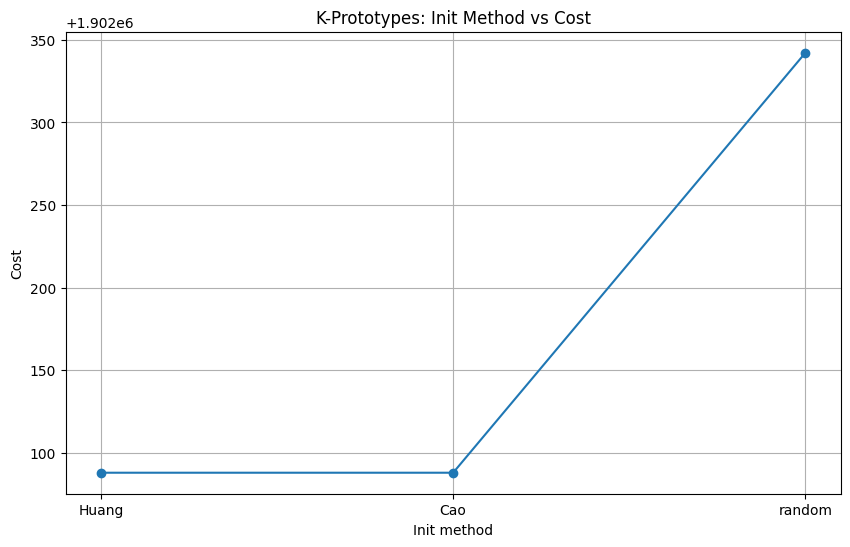

In [34]:
from kmodes.kprototypes import KPrototypes
def find_init_kproto(data, categorical_idx):
    init_tuning = ['Huang', 'Cao', 'random']
    cost = []

    for init in init_tuning:
        kproto = KPrototypes(n_clusters=4, init=init, random_state=42, n_jobs=-1)
        clusters = kproto.fit_predict(data, categorical=categorical_idx)
        cost.append(kproto.cost_)
        print(f'Cost for init method {init}: {kproto.cost_}')

    plt.figure(figsize=(10, 6))
    plt.plot(init_tuning, cost, marker='o')
    plt.xlabel('Init method')
    plt.ylabel('Cost')
    plt.title('K-Prototypes: Init Method vs Cost')
    plt.grid(True)
    plt.show()
find_init_kproto(data_matrix, categorical_idx)

Cost for n_init = 4: 1902087.9903716175
Cost for n_init = 8: 1902087.9903716175
Cost for n_init = 12: 1902087.9903716175
Cost for n_init = 16: 1902087.9903716175
Cost for n_init = 20: 1902087.9903716175


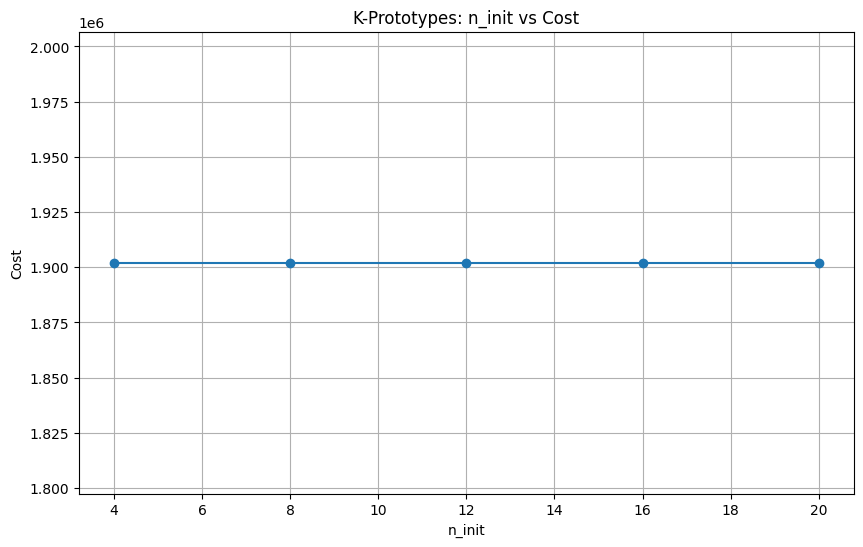

In [ ]:
def find_ninit_kproto(data, categorical_idx):
    ninit_tuning = [4, 8, 12, 16, 20]
    cost = []

    for ninit in ninit_tuning:
        kproto = KPrototypes(n_clusters=4, init='Huang', n_init=ninit, random_state=42, n_jobs=-1)
        clusters = kproto.fit_predict(data, categorical=categorical_idx)
        cost.append(kproto.cost_)
        print(f'Cost for n_init = {ninit}: {kproto.cost_}')

    plt.figure(figsize=(10, 6))
    plt.plot(ninit_tuning, cost, marker='o')
    plt.xlabel('n_init')
    plt.ylabel('Cost')
    plt.title('K-Prototypes: n_init vs Cost')
    plt.grid(True)
    plt.show()

find_ninit_kproto(data_matrix, categorical_idx)

Cost for max_iter = 100: 1902087.9903716175
Cost for max_iter = 200: 1902087.9903716175
Cost for max_iter = 300: 1902087.9903716175


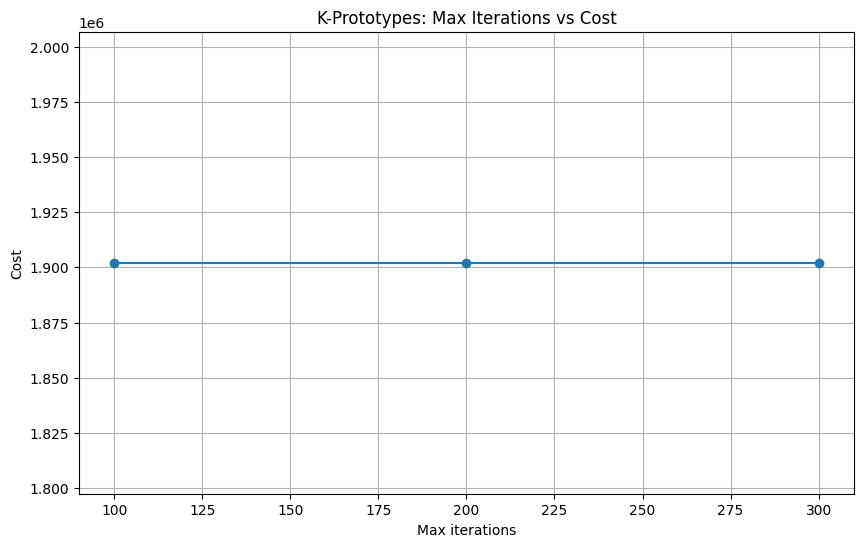

In [36]:
def find_max_kproto(data, categorical_idx):
    max_tuning = [100, 200, 300]
    cost = []

    for max_iter in max_tuning:
        kproto = KPrototypes(n_clusters=4, init='Huang', n_init=12, max_iter=max_iter, random_state=42, n_jobs=-1)
        clusters = kproto.fit_predict(data, categorical=categorical_idx)
        cost.append(kproto.cost_)
        print(f'Cost for max_iter = {max_iter}: {kproto.cost_}')

    plt.figure(figsize=(10, 6))
    plt.plot(max_tuning, cost, marker='o')
    plt.xlabel('Max iterations')
    plt.ylabel('Cost')
    plt.title('K-Prototypes: Max Iterations vs Cost')
    plt.grid(True)
    plt.show()

find_max_kproto(data_matrix, categorical_idx)

In [37]:
def find_num_clusters_kproto(data, categorical_idx, k):
    iters = range(1, k)
    cost = []

    for i in iters:
        kproto = KPrototypes(
            n_clusters=i,
            init='Huang',
            n_init=12,
            max_iter=100,
            random_state=42,
            verbose=0,
            n_jobs=-1
        )
        clusters = kproto.fit_predict(data, categorical=categorical_idx)
        cost.append(kproto.cost_)
        print(f'Cost for k = {i}: {kproto.cost_}')

    plt.figure(figsize=(10, 6))
    plt.plot(list(iters), cost, 'x-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Cost')
    plt.title('K-Prototypes Elbow Curve')
    plt.grid(True)
    plt.show()

find_num_clusters_kproto(data_matrix, categorical_idx, 15)

Cost for k = 1: 3010690.0000000866
Cost for k = 2: 2555225.0023830016
Cost for k = 3: 2222509.9322043373
Cost for k = 4: 1902087.9903716175
Cost for k = 5: 1615094.6252881764
Cost for k = 6: 1535081.3934472075
Cost for k = 7: 1451823.6527010216
Cost for k = 8: 1399529.3122814193
Cost for k = 9: 1354984.2557908008
Cost for k = 10: 1319797.0668954456


: 

: 

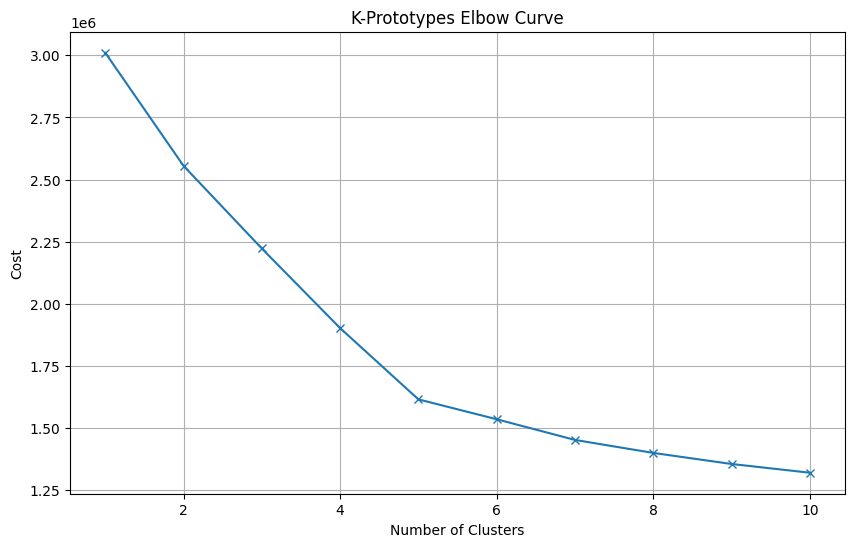

In [30]:
from kmodes.kprototypes import KPrototypes
iters = [1,2,3,4,5,6,7,8,9,10]
cost = [3010690.0000000866, 2555225.0023830016, 2222509.9322043373, 1902087.9903716175, 1615094.6252881764, 1535081.3934472075, 1451823.6527010216, 1399529.3122814193, 1354984.2557908008, 1319797.0668954456]

plt.figure(figsize=(10, 6))
plt.plot(list(iters), cost, 'x-')
plt.xlabel('Number of Clusters')
plt.ylabel('Cost')
plt.title('K-Prototypes Elbow Curve')
plt.grid(True)
plt.show()

In [31]:
cost = []
k = 5
kproto = KPrototypes(
    n_clusters=k,
    init='Huang',
    n_init=12,
    max_iter=100,
    random_state=42,
    n_jobs=-1
)

clusters = kproto.fit_predict(data_matrix, categorical=categorical_idx)

cost.append(kproto.cost_)
print(cost)

df_cluster_fin['Clusters'] = clusters

[np.float64(1615094.6252881764)]


In [32]:
numeric_profile = df_cluster_fin.groupby('Clusters')[numeric_cols].mean()
display(numeric_profile)

,is_student_status,is_retired_status,language_count,years_code_clean,professional_experience_years,database_count,platform_count
Clusters,,,,,,,
0,1.000000,0.0,5.711061,7.616175,4.144812,2.826777,2.950007
1,0.006614,0.0,4.874203,25.956095,20.006113,2.416457,2.486948
2,0.062619,1.0,5.746331,29.827368,26.207243,3.357527,3.030928
3,0.014513,0.0,7.733084,12.466878,7.788901,4.830959,5.006033
4,0.000000,0.0,3.756051,8.481652,5.439120,1.939323,2.051218


In [ ]:
for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(pd.crosstab(df_cluster_fin['Clusters'], df_cluster_fin[col], normalize='index'))

In [34]:
print(kproto.cluster_centroids_)

[['3.24780815105021' '-0.03957237576673677' '0.36923910372217383'
  '-0.5040763331233541' '-0.5809947084413736' '0.08797080982824225'
  '0.10290555178180796' 'Europe' '25-34' 'Employed full-time'
  "Bachelor's" 'Developer, full-stack' 'Software Development' '100-999'
  'Mostly in-person']
 ['-0.2843819310336099' '-0.03957237576672224' '0.062007005355203836'
  '1.6629810841594934' '1.6946392173536864' '-0.13365177041111204'
  '-0.1364078939797434' 'Europe' '35-44' 'Employed full-time'
  'Postgraduate' 'Developer, full-stack' 'Software Development' '100-999'
  'Mostly in-person']
 ['-0.08524651098046584' '25.270153247680906' '0.38103957254595316'
  '1.9154789173749944' '2.448490307453369' '0.3306432995223704'
  '0.10020011686602624' 'Americas' '55+' 'Independent / contract'
  "Bachelor's" 'Developer, full-stack' 'Software Development' '100-999'
  'Mostly in-person']
 ['-0.2562963183876825' '-0.03957237576675244' '1.2270559641955592'
  '0.06813397653050371' '-0.07031955714039453' '1.42764

In [35]:
centroids = kproto.cluster_centroids_

n_num = len(numeric_cols)
n_cat = len(categorical_cols)

centroids_num = pd.DataFrame(
    centroids[:, :n_num].astype(float),
    columns=numeric_cols,
    index=[f'Cluster_{i+1}' for i in range(k)]
)

centroids_cat = pd.DataFrame(
    centroids[:, n_num:],
    columns=categorical_cols,
    index=[f'Cluster_{i+1}' for i in range(k)]
)

print("Numeric centroids:")
display(centroids_num)

print("\nCategorical centroids:")
display(centroids_cat)

Numeric centroids:


,is_student_status,is_retired_status,language_count,years_code_clean,professional_experience_years,database_count,platform_count
Cluster_1,3.247808,-0.039572,0.369239,-0.504076,-0.580995,0.087971,0.102906
Cluster_2,-0.284382,-0.039572,0.062007,1.662981,1.694639,-0.133652,-0.136408
Cluster_3,-0.085247,25.270153,0.381040,1.915479,2.448490,0.330643,0.100200
Cluster_4,-0.256296,-0.039572,1.227056,0.068134,-0.070320,1.427646,1.409270
Cluster_5,-0.307900,-0.039572,-0.351730,-0.400806,-0.368214,-0.306648,-0.303109



Categorical centroids:


,region,age_group,employment_primary,education_clean,dev_type,industry,org_size_clean,remote_group
Cluster_1,Europe,25-34,Employed full-time,Bachelor's,"Developer, full-stack",Software Development,100-999,Mostly in-person
Cluster_2,Europe,35-44,Employed full-time,Postgraduate,"Developer, full-stack",Software Development,100-999,Mostly in-person
Cluster_3,Americas,55+,Independent / contract,Bachelor's,"Developer, full-stack",Software Development,100-999,Mostly in-person
Cluster_4,Europe,25-34,Employed full-time,Bachelor's,"Developer, full-stack",Software Development,100-999,Mostly in-person
Cluster_5,Europe,25-34,Employed full-time,Bachelor's,"Developer, full-stack",Software Development,100-999,Mostly in-person


In [36]:
for cluster_name, row in centroids_num.iterrows():
    print(f"\n{cluster_name}")

    strongest_positive = row.sort_values(ascending=False).head(5)
    strongest_negative = row.sort_values(ascending=True).head(5)

    print("Top positive numeric features:")
    print(strongest_positive)
    print("\nTop negative numeric features:")
    print(strongest_negative)
    print("\nCategorical profile:")
    print(centroids_cat.loc[cluster_name])


Cluster_1
Top positive numeric features:
is_student_status    3.247808
language_count       0.369239
platform_count       0.102906
database_count       0.087971
is_retired_status   -0.039572
Name: Cluster_1, dtype: float64

Top negative numeric features:
professional_experience_years   -0.580995
years_code_clean                -0.504076
is_retired_status               -0.039572
database_count                   0.087971
platform_count                   0.102906
Name: Cluster_1, dtype: float64

Categorical profile:
region                               Europe
age_group                             25-34
employment_primary       Employed full-time
education_clean                  Bachelor's
dev_type              Developer, full-stack
industry               Software Development
org_size_clean                      100-999
remote_group               Mostly in-person
Name: Cluster_1, dtype: object

Cluster_2
Top positive numeric features:
professional_experience_years    1.694639
years_code_cl